# Análisis del Hitting Time en Caminatas Aleatorias


Este reporte analiza el comportamiento del **Hitting Time** en función del tamaño y la dimensión de la caminata aleatoria.
Se han realizado simulaciones en diferentes dimensiones y tamaños, recopilando estadísticas para evaluar cómo evoluciona el tiempo de hitting en cada configuración.
También se explora la relación con el **Teorema de Recurrencia de Poincaré**, el cual establece que en dimensiones mayores a 2, un walker no tiene garantía de regresar a su punto de origen.


In [1]:

import pandas as pd

# Cargar el archivo de datos
csv_path = "../data/symmetry_walks.csv"
df = pd.read_csv(csv_path)

# Mostrar las primeras filas
df.head()


,Dimension,Size,Hitting Time,STD,Max
0,1D,4,3.9588,2.770642,22.2
1,1D,8,16.1406,12.891358,98.0
2,1D,16,64.1510,51.400118,379.8
3,1D,32,255.0774,207.619108,1610.2
4,1D,64,1031.6994,832.090780,6200.0



## Análisis Exploratorio

A continuación, se exploran las dimensiones y tamaños disponibles en el dataset para comprender la distribución de los datos.


In [2]:

# Dimensiones y tamaños disponibles en el dataset
unique_dimensions = df["Dimension"].unique()
unique_sizes = df["Size"].unique()

unique_dimensions, unique_sizes


(array(['1D', '2D', '3D', '4D', '5D', '6D', '8D', '12D', '16D', '32D',
        '64D', '128D', '256D'], dtype=object),
 array([  4,   8,  16,  32,  64, 128], dtype=int64))


## Hitting Time vs Size

La siguiente gráfica muestra cómo evoluciona el **Hitting Time** en función del tamaño en cada dimensión.


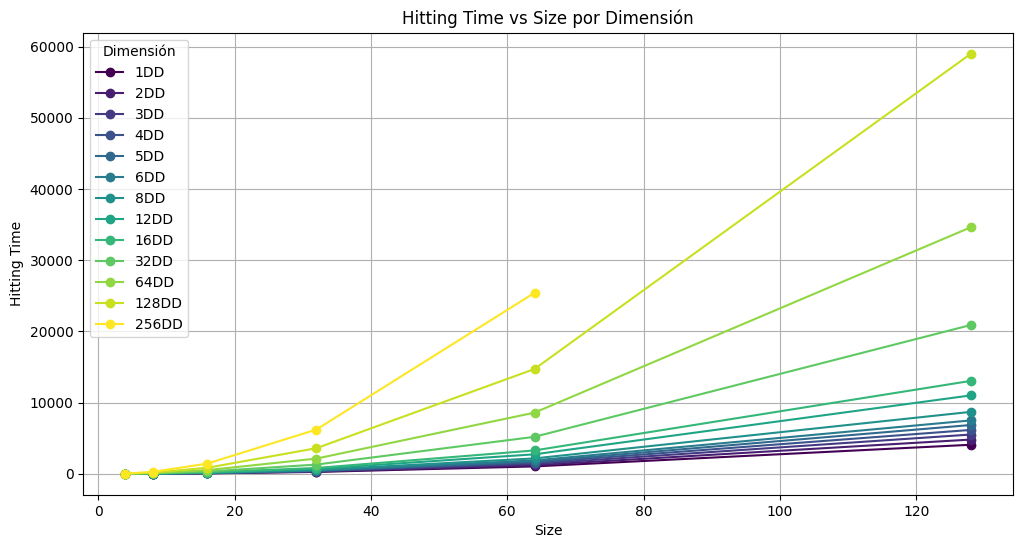

In [3]:

import matplotlib.pyplot as plt
import numpy as np

# Convertir a numérico por seguridad
df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

# Filtrar y ordenar por Size
df_sorted = df.sort_values(by=["Dimension", "Size"])

# Colores para cada dimensión
colors = plt.cm.viridis(np.linspace(0, 1, len(df["Dimension"].unique())))

plt.figure(figsize=(12, 6))

for i, dim in enumerate(df["Dimension"].unique()):
    subset = df_sorted[df_sorted["Dimension"] == dim]
    plt.plot(subset["Size"], subset["Hitting Time"], marker="o", linestyle="-", label=f"{dim}D", color=colors[i])

plt.xlabel("Size")
plt.ylabel("Hitting Time")
plt.title("Hitting Time vs Size por Dimensión")
plt.legend(title="Dimensión")
plt.grid(True)
plt.show()



## Relación con el Teorema de Poincaré

El **Teorema de Recurrencia de Poincaré** establece que en dimensiones 1 y 2, un walker aleatorio siempre regresará a su punto de origen en un tiempo finito.
Sin embargo, en dimensiones 3 o superiores, no hay garantías de que esto ocurra. Esto explica por qué el **Hitting Time** crece exponencialmente con la dimensión en nuestras simulaciones.

Podemos representar matemáticamente la probabilidad de retorno en una caminata aleatoria como:

\[ P_{	ext{retorno}} = 1, \quad 	ext{para } d = 1, 2 \]
\[ P_{	ext{retorno}} < 1, \quad 	ext{para } d \geq 3 \]

Donde **d** es la dimensión de la caminata aleatoria.



## Comparación entre el Hitting Time Medio y el Máximo

Para comprender mejor la variabilidad del hitting time, analizamos cómo se comparan los valores máximos y la media en cada dimensión.


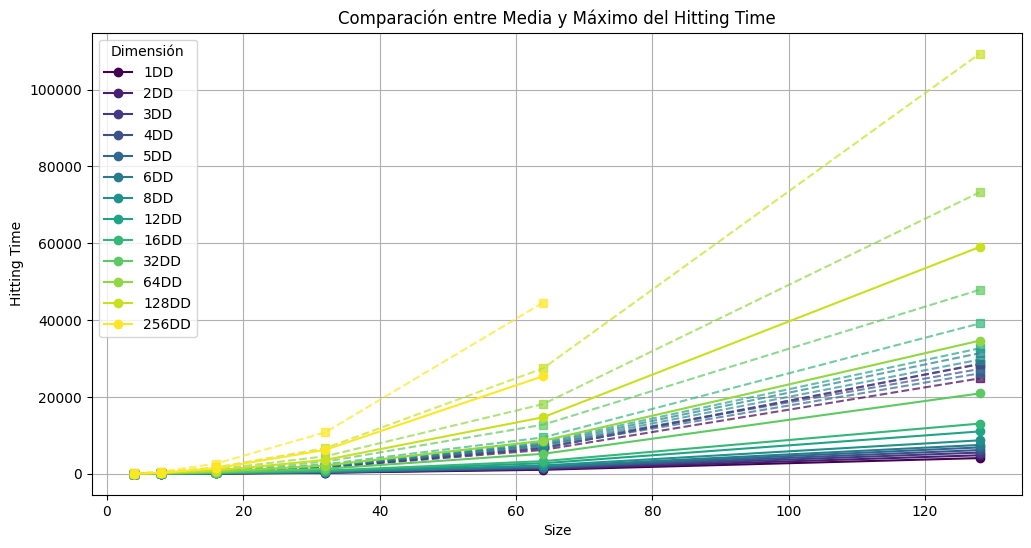

In [4]:

plt.figure(figsize=(12, 6))

for i, dim in enumerate(df["Dimension"].unique()):
    subset = df_sorted[df_sorted["Dimension"] == dim]
    plt.plot(subset["Size"], subset["Hitting Time"], marker="o", linestyle="-", label=f"{dim}D", color=colors[i])
    plt.plot(subset["Size"], subset["Max"], marker="s", linestyle="--", color=colors[i], alpha=0.7)

plt.xlabel("Size")
plt.ylabel("Hitting Time")
plt.title("Comparación entre Media y Máximo del Hitting Time")
plt.legend(title="Dimensión")
plt.grid(True)
plt.show()



## Conclusiones

Los resultados obtenidos confirman la teoría del **Teorema de Poincaré** y los principios de caminatas aleatorias:

- En **1D y 2D**, el walker eventualmente alcanza el objetivo en un tiempo finito, lo que se refleja en un crecimiento más controlado del **Hitting Time**.
- A partir de **3D**, el crecimiento del **Hitting Time** es exponencial, indicando que el walker tiene cada vez menos probabilidades de alcanzar su objetivo.
- El **Hitting Time máximo** crece más rápido que la media en dimensiones altas, lo que sugiere que algunos walkers tardan mucho más en alcanzar un extremo.

Estos resultados tienen aplicaciones en **modelos de difusión, física estadística y redes complejas**, donde la dimensión del espacio afecta la probabilidad de alcanzar un estado particular.
